**Assignment 05 - Feature Engineering & Regression Modeling**

## Part A - Data Cleaning & Preparation

In this section, we will clean and prepare the dataset before modeling.  
The following steps will be performed:

1. **Load the dataset**  
   - Check the shape (rows × columns).  
   - Inspect data types (`dtypes`).  
   - Generate summary statistics.

2. **Identify data issues**  
   - Report missing values.  
   - Detect duplicate rows.  
   - Find inconsistent categorical labels (e.g., "Male", "male", "M").  
   - Identify invalid or outlier values.

3. **Clean the dataset**  
   - Remove duplicate rows.  
   - Standardize categorical text (make labels consistent).  
   - Fix incorrect data types (e.g., convert strings to numeric).  
   - Handle outliers (justify chosen method such as IQR or Z-score).

4. **Handle missing values**  
   - Apply at least two different strategies:  
     - **Numeric columns:** e.g., mean/median imputation.  
     - **Categorical columns:** e.g., mode imputation or forward-fill.  
   - Provide justification for each strategy.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')




**Part A - Data Cleaning & Preparation**

In [ ]:
# 1.Load the dataset
df= pd.read_csv("/content/student_dataset_dirty - student_dataset_dirty.csv")

#copy data set
df_copy= df.copy()
print("Copy the dataset :", df_copy)

# Check the Shape (Rows X Coloumns)
print("Shape:",df.shape)

# Check Inspect data Type
print("\n Data Type :")
print(df.dtypes)

# Generate Summary Statistics
print("\n Summary Statistics : ")
print (df.describe(include="all"))




Copy the dataset :      Student_ID              Name  Age  Gender        City  Class  \
0          1978       Bristi Khan   16    MALE  Mymensingh  Eight   
1          3881       hasan akter   12       F       Dhaka   10th   
2            53    Sohan Talukder   14    Male      Khulna    7th   
3          2552      Mitu Hossain   11  FEMALE    Rajshahi    Ten   
4          2247      Ayesha Ahmed   14   other      KHULNA    9th   
...         ...               ...  ...     ...         ...    ...   
9995        920      Rafi Hossain   15     NaN       Dacca      6   
9996       4308         Mim Akter   11    male     barisal      9   
9997       5700      Tamim Rahman  -18       O  Chittagong   Nine   
9998        538     Farhan Rahman   18  female  Chattogram      6   
9999       9413  Ayesha Chowdhury   17       O     rangpur      9   

      Attendance_Percentage  Study_Hours_per_day Math_Score Science_Score  \
0                      77.0                  2.6         83            62  

In [ ]:
# Report missing values
print("Missing Values per column :\n",df.isnull().sum())

#Report Duplicate Rows
print("\n Number of Duplicate Rows :",df.duplicated().sum())

#Check for inconsistent Categorical Label
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  print(f"\n Unique Labels in '{col}' (total: {df[col].nunique()}):")
  print(df[col].unique())

# Example: unify gender labels
if 'gender'in df.columns :
    df['gender'] = df['gender'].replace({'male': 'Male','m':'Male','female':'Female','f':'Female'})

# Example: unify result labels if present
if'result' in df.columns:
  df['result'] = df['result'].replace({'pass':'Pass','p':'Pass','fail':'Fail','f':'Fail'})


Missing Values per column :
 Student_ID                  0
Name                       42
Age                       196
Gender                    838
City                      225
Class                       0
Attendance_Percentage     255
Study_Hours_per_day       197
Math_Score                195
Science_Score             200
English_Score             196
Total_Score               316
Parent_Education         1100
Internet_Access          1646
Result                   1094
dtype: int64

 Number of Duplicate Rows : 150

 Unique Labels in 'Student_ID' (total: 9850):
['1978' '3881' '53' ... '5700' '538' '9413']

 Unique Labels in 'Name' (total: 385):
['Bristi Khan' 'hasan akter' 'Sohan Talukder' 'Mitu Hossain'
 'Ayesha Ahmed' 'Jannat Hossain' 'Imran Ahmed' 'Rakib Chowdhury'
 'Nadia Islam' 'Momo Ahmed' 'Nusrat Talukder' 'Rakib Das' 'Mim Rahman'
 'Jannat Akter' 'Imran Hossain' 'Nusrat Das' 'Zayed Das' 'Zayed Rahman'
 'Imran Khan' 'Farhan Ahmed' 'Karim Chowdhury' 'Kabir Das' 'Kabir Khan'
 '

In [ ]:

print("***Starting Data Cleaning Process ***")

# Remove Duplicate Rows
initial_row = len(df)
df = df.drop_duplicates()
print(f"Duplicates Handled : Removed {initial_row - len(df)} duplicate rows.")

# Standardize Categorical Label (Lower case,Strip spaces)
for col in categorical_cols:
  df[col] = df[col].str.lower().str.strip()

# Convert score columns to numeric
score_cols = ['Math_Score','Science_Score','English_Score','Total_Score']
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert attendance and study hours to numeric
df['Attendance_Percentage'] = pd.to_numeric(df['Attendance_Percentage'], errors='coerce')
df['Study_Hours_per_day'] = pd.to_numeric(df['Study_Hours_per_day'], errors='coerce')

# Separate numerical and categorical columns from your dataset
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Outlier handling using IQR
for col in ['Math_Score','Science_Score','English_Score','Total_Score']:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df.loc[(df[col]<lower_bound)|(df[col]>upper_bound),col] = np.nan


***Starting Data Cleaning Process ***
Duplicates Handled : Removed 150 duplicate rows.


In [ ]:
print("***Starting Data Cleaning Process ***")

# Drop 'Student_ID' and 'Name' columns as they are identifiers and not features
df = df.drop(columns=['Student_ID', 'Name'], errors='ignore')
print("Dropped 'Student_ID' and 'Name' columns.")

# Re-evaluate numerical and categorical columns after dropping 'Student_ID' and 'Name'
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Handle missing values in numerical columns using Median Imputation
for col in num_cols:
  if df[col].isnull().any(): # Only impute if there are missing values
    df[col] = df[col].fillna(df[col].median())

# Handle missing values in categorical colums using Mode Imputation
# Exclude 'Result' if it's the target for classification and will be handled separately later
for col in cat_cols:
  if col != 'Result' and df[col].isnull().any(): # Only impute if there are missing values and not 'Result'
    if not df[col].mode().empty:
      df[col] = df[col].fillna(df[col].mode()[0])

# For the 'Result' column, if there are NaNs, we'll drop those rows later for classification,
# or handle them specifically if needed for other tasks.

# Verify that all missing values in feature columns have been successfully handled
# Dropping rows where 'Total_Score' or 'Result' (if applicable) is NaN for robustness
df.dropna(subset=['Total_Score'], inplace=True)
print("Dropped rows with missing 'Total_Score' for Linear Regression.")

print("\n Missing Values after final cleaning : \n", df.isna().sum())
print("***Data Cleaning Process Complete ***")

***Starting Data Cleaning Process ***
Dropped 'Student_ID' and 'Name' columns.
Dropped rows with missing 'Total_Score' for Linear Regression.

 Missing Values after final cleaning : 
 Age                         0
Gender                      0
City                        0
Class                       0
Attendance_Percentage       0
Study_Hours_per_day         0
Math_Score                  0
Science_Score               0
English_Score               0
Total_Score                 0
Parent_Education            0
Internet_Access             0
Result                   1081
dtype: int64
***Data Cleaning Process Complete ***


# Part B - Feature Engineering

In this section, we will engineer features to improve model performance.  
The following steps will be performed:

1. **Encode categorical variables**  
   - Convert categorical columns (`Gender, City, Class, Parent_Education, Internet_Access`) into numeric form.  
   - Use **One-Hot Encoding** for nominal variables (no order).  
   - Use **Label Encoding** for ordinal variables (ordered categories like Class).  

2. **Scale numeric features**  
   - Apply scaling so all numeric features are on the same scale.  
   - Options: **StandardScaler** (mean=0, std=1) or **MinMaxScaler** (range 0–1).  

3. **Create new features**  
   - `Average_Score` = mean of Math, Science, English scores.  
   - `Study_Efficiency` = Average_Score ÷ Study_Hours_per_day.  
   - `Attendance_Category` = bucketed attendance percentage (Low, Medium, High).  

4. **Feature selection**  
   - Perform correlation/statistical tests against the target variable (`Result`) to identify important features.


****Encoding Categorical Variables ****



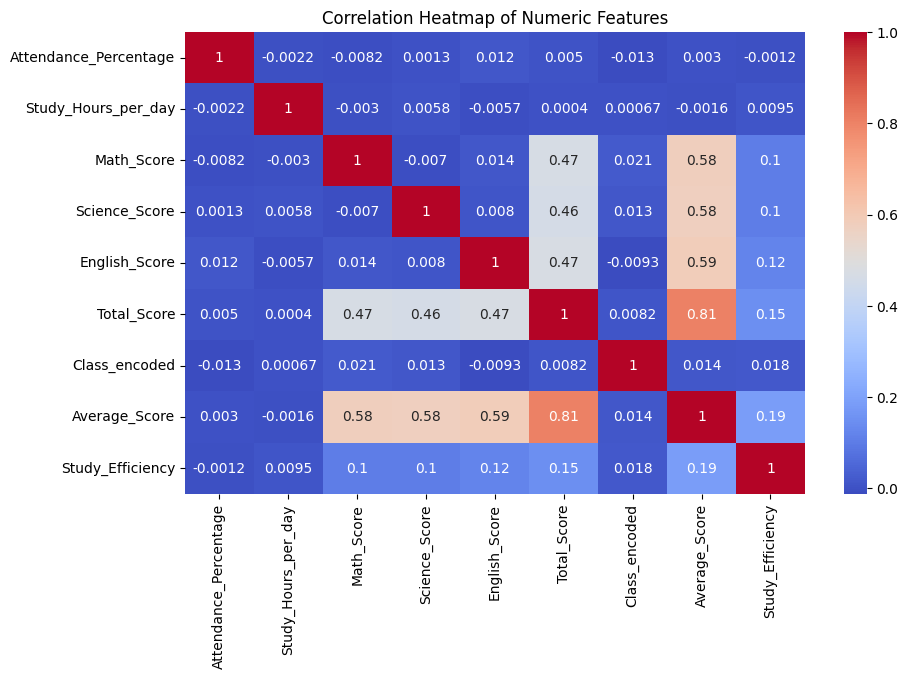

In [ ]:
# Encode Categorical variables
print("\n****Encoding Categorical Variables ****\n")

# Check if 'Class' column exists before encoding
if 'Class' in df.columns:
    le = LabelEncoder()
    df['Class_encoded'] = le.fit_transform(df['Class'])
else:
    print("Warning: 'Class' column not found for Label Encoding.")

# One Hot Encoding for nominal Categorical Variables
cols_to_encode = ['Gender','City','Parent_Education','Internet_Access']

# Filter out columns that are already gone due to previous execution
present_cols_to_encode = [col for col in cols_to_encode if col in df.columns]

if present_cols_to_encode:
    df = pd.get_dummies(df, columns=present_cols_to_encode, drop_first=True)
else:
    print("Warning: No nominal categorical columns found for One-Hot Encoding (they might already be encoded).")

# Scale numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude 'Student_ID' if it's treated as an identifier and not a feature for scaling
if 'Student_ID' in num_cols:
    num_cols.remove('Student_ID')

# Ensure only valid numeric columns are scaled
scale_cols = ['Math_Score','Science_Score','English_Score','Total_Score','Attendance_Percentage','Study_Hours_per_day']

# Filter to only include columns that are actually numeric in the df
current_numeric_cols = [col for col in scale_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

if current_numeric_cols:
    scaler = StandardScaler()
    df[current_numeric_cols] = scaler.fit_transform(df[current_numeric_cols])
else:
    print("Warning: No numeric columns found for scaling.")

# Create New Features
if all(col in df.columns for col in ['Math_Score', 'Science_Score', 'English_Score']):
    df['Average_Score'] = df[['Math_Score','Science_Score','English_Score']].mean(axis=1)
else:
    print("Warning: Cannot create 'Average_Score' as Math_Score, Science_Score, or English_Score are missing.")
    df['Average_Score'] = np.nan # Or handle as appropriate

if 'Study_Hours_per_day' in df.columns and 'Average_Score' in df.columns:
    # Add a small constant to prevent division by zero if Study_Hours_per_day can be zero or negative
    df['Study_Efficiency'] = df['Average_Score'] / (df['Study_Hours_per_day'].replace(0, np.nan).fillna(1) + 1)
else:
    print("Warning: Cannot create 'Study_Efficiency' as Study_Hours_per_day or Average_Score are missing.")
    df['Study_Efficiency'] = np.nan # Or handle as appropriate

if 'Attendance_Percentage' in df.columns:
    df['Attendance_Category'] = pd.cut(df['Attendance_Percentage'],bins = [-np.inf, 75, 100, np.inf],labels = ['Low','Medium','High'], right=False)
else:
    print("Warning: 'Attendance_Percentage' column not found for creating 'Attendance_Category'.")

# Feature Selection using correlation
heatmap_cols = [col for col in num_cols + ['Average_Score', 'Study_Efficiency'] if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

if heatmap_cols:
    plt.figure(figsize = (10,6))
    sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap = 'coolwarm')
    plt.title("Correlation Heatmap of Numeric Features")
    plt.show()
else:
    print("Warning: No numeric features available for correlation heatmap.")

# Correlation with target (if 'Result' exists)
if 'Result' in df.columns:
    if pd.api.types.is_numeric_dtype(df['Result']):
        print("\nCorrelation with Result:\n", df.corr(numeric_only=True)['Result'].sort_values(ascending=False))
    else:
        print("Warning: 'Result' column is not numeric, cannot calculate correlation.")
else:
    print("Warning: 'Result' column not found for target correlation.")

In [ ]:

print("***Starting Data Cleaning Process ***")

# Remove Duplicate Rows
initial_row = len(df)
df = df.drop_duplicates()
print(f"Duplicates Handled : Remove {initial_row - len(df)} duplicate rows.")

# Standardize Categorical Label (Lower case,Strip spaces)
categorical_cols = ['Gender','City','Parent_Education','Internet_Access']
for col in categorical_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip()

# Convert score columns to numeric
score_cols = ['Math_Score','Science_Score','English_Score','Total_Score']
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert attendance and study hours to numeric
df['Attendance_Percentage'] = pd.to_numeric(df['Attendance_Percentage'], errors='coerce')
df['Study_Hours_per_day'] = pd.to_numeric(df['Study_Hours_per_day'], errors='coerce')

# Separate numerical and categorical columns from your dataset
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Outlier handling using IQR
for col in ['Math_Score','Science_Score','English_Score','Total_Score']:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df.loc[(df[col]<lower_bound)|(df[col]>upper_bound),col] = np.nan


***Starting Data Cleaning Process ***
Duplicates Handled : Remove 0 duplicate rows.


# Part C - Linear Regression

In this section, we will build and evaluate a Linear Regression model to predict **Total_Score**.

### Steps:
1. **Train-test split (80/20)**  
   - Split the dataset into training (80%) and testing (20%) sets.  

2. **Train Linear Regression**  
   - Exclude individual subject scores (`Math_score`, `Science_score`, `English_score`) because they are directly summed into `Total_Score`.  
   - Including them would cause data leakage (model would trivially learn the sum).  

3. **Plot Actual vs Predicted**  
   - Visualize how well the model predicts `Total_Score` on the test set.  

4. **Interpret model coefficients**  
   - Understand the impact of features (e.g., Attendance, Study Hours, Parent Education, Internet Access) on `Total_Score`.  


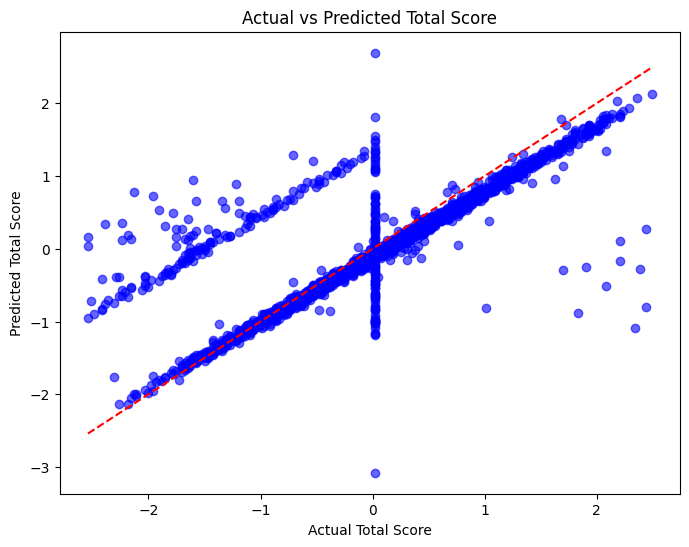


Interpreting Coefficients : 
            Feature  Coefficient
32   Average_Score     1.375705
114        Age_268     0.622689
40         Age_-17     0.374197
127        Age_298     0.324328
79         Age_190     0.318557
..             ...          ...
48          Age_-7    -1.524987
96         Age_223    -1.567672
77         Age_187    -1.715786
62         Age_160    -2.084361
91         Age_216    -2.638219

[148 rows x 2 columns]


In [ ]:
# Train-test split
x = pd.get_dummies(
    df.drop(columns=['Math_Score','Science_Score','English_Score','Total_Score']),
    drop_first=True
)
y = df['Total_Score']

# Combine x and y to drop rows with NaN values consistently
df_combined = pd.concat([x, y], axis=1)
df_combined.dropna(inplace=True)

x = df_combined.drop(columns=['Total_Score'])
y = df_combined['Total_Score']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)

# Plot Actual vs Predicted
plt.figure(figsize = (8,6))
plt.scatter(y_test,y_pred,color = 'blue',alpha = 0.6)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color = 'red',linestyle = '--')
plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Total Score")
plt.show()

# Interpret coefficients
coefficients = pd.DataFrame({'Feature':x_train.columns,'Coefficient':model.coef_}).sort_values(by = 'Coefficient',ascending =  False)
print("\nInterpreting Coefficients : \n",coefficients)

# Part D - Logistic Regression

In this section, we will build and evaluate a Logistic Regression model to predict **Result (Pass/Fail)**.

### Steps:
1. **Clean and binary-encode the target**  
   - Handle inconsistencies in labels (e.g., "P", "pass", "FAIL").  
   - Encode target as binary (Pass=1, Fail=0).  

2. **Stratified train-test split (80/20)**  
   - Use stratification to preserve class distribution in both train and test sets.  

3. **Train Logistic Regression**  
   - Fit the model on training data and evaluate on test data.  

4. **Check class imbalance**  
   - Report class distribution.  
   - Discuss how imbalance can affect model performance (e.g., bias toward majority class).  

5. **Interpret coefficients**  
   - Convert coefficients to odds/log-odds.  
   - Explain at least two features’ impact on probability of passing.  


In [ ]:
# Clean target
df['Result'] = df['Result'].str.strip().str.lower()
df['Result'] = df['Result'].replace({'p':'pass','pass':'pass','f':'fail','fail':'fail'})
df['Result'] = df['Result'].map({'pass':1,'fail':0})

# Features (drop leakage columns)
x = pd.get_dummies(
    df.drop(columns=['Result','Math_Score','Science_Score','English_Score','Total_Score']),
    drop_first=True
)
y = df['Result']

# Drop NaN rows consistently
df_clean = pd.concat([x, y], axis=1).dropna()
x = df_clean.drop(columns=['Result'])
y = df_clean['Result']

# OUTPUT SECTION

print("="*60)
print("LOGISTIC REGRESSION ANALYSIS")
print("="*60)

# 1. CLASS DISTRIBUTION AND IMBALANCE CHECK
print("\n1. CLASS DISTRIBUTION:")
print("-"*40)
class_dist = y.value_counts()
print(f"Pass (1): {class_dist.get(1, 0):,} students ({class_dist.get(1, 0)/len(y)*100:.2f}%)")
print(f"Fail (0): {class_dist.get(0, 0):,} students ({class_dist.get(0, 0)/len(y)*100:.2f}%)")

# Check for imbalance
if class_dist.get(1, 0) > class_dist.get(0, 0) * 1.5 or class_dist.get(0, 0) > class_dist.get(1, 0) * 1.5:
    print("\n CLASS IMBALANCE DETECTED: One class is significantly larger than the other")
    print("   This can lead to:")
    print("   • Model bias toward the majority class")
    print("   • Poor recall for the minority class")
    print("   • Overly optimistic accuracy that doesn't reflect true performance")
    print("   • Consider using class_weight='balanced' or oversampling techniques")
else:
    print("\n Class distribution is relatively balanced")

# Stratified train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

# Predictions
y_pred = log_model.predict(x_test)

# 2. MODEL PERFORMANCE
print("\n" + "="*60)
print("2. MODEL PERFORMANCE ON TEST DATA:")
print("-"*40)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"               Fail  Pass")
print(f"Actual Fail    {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       Pass    {cm[1,0]:3d}   {cm[1,1]:3d}")

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

# 3. COEFFICIENT INTERPRETATION
print("\n" + "="*60)
print("3. COEFFICIENT INTERPRETATION (Odds Ratios):")
print("-"*40)

# Get feature names and coefficients
feature_names = x.columns
coefficients = log_model.coef_[0]

# Create a dataframe for easier interpretation
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)  # Convert to odds ratio
})

# Sort by absolute coefficient value (most influential first)
coef_df['Abs_Coeff'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coeff', ascending=False)

print("\nTop 10 Most Influential Features:")
print(coef_df.head(10).to_string(index=False))

print("\n" + "-"*40)
print("INTERPRETATION GUIDE:")
print("- A positive coefficient increases the log-odds of passing")
print("- A negative coefficient decreases the log-odds of passing")
print("- Odds Ratio > 1: Feature increases passing probability")
print("- Odds Ratio < 1: Feature decreases passing probability")
print("- Odds Ratio = 1: No effect on passing probability")

# 4. DETAILED FEATURE ANALYSIS (Top 2 features)
print("\n" + "="*60)
print("4. DETAILED ANALYSIS: TOP 2 FEATURES")
print("-"*40)

# Get top 2 features by absolute coefficient
top_features = coef_df.head(2)

for idx, row in top_features.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    odds = row['Odds_Ratio']

    print(f"\nFeature: {feature}")
    print(f"  • Coefficient (log-odds): {coef:.4f}")
    print(f"  • Odds Ratio: {odds:.4f}")

    if odds > 1:
        impact = (odds - 1) * 100
        print(f"  • Impact: A 1-unit increase in {feature} increases the odds of passing by {impact:.1f}%")
        print(f"  • Interpretation: Students with higher {feature} are more likely to pass")
    elif odds < 1:
        impact = (1 - odds) * 100
        print(f"  • Impact: A 1-unit increase in {feature} decreases the odds of passing by {impact:.1f}%")
        print(f"  • Interpretation: Students with higher {feature} are less likely to pass")
    else:
        print(f"  • Impact: {feature} has no effect on passing probability")

# 5. MODEL EVALUATION SUMMARY
print("\n" + "="*60)
print("5. MODEL EVALUATION SUMMARY")
print("-"*40)

# Calculate key metrics
tn, fp, fn, tp = cm.ravel()
precision_pass = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pass = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pass = 2 * (precision_pass * recall_pass) / (precision_pass + recall_pass) if (precision_pass + recall_pass) > 0 else 0

print(f"Precision (Pass): {precision_pass:.4f}")
print(f"Recall (Pass): {recall_pass:.4f}")
print(f"F1-Score (Pass): {f1_pass:.4f}")

# Check for bias
if precision_pass > recall_pass * 1.2:
    print("\n Possible Precision-Recall imbalance: Model may be conservative in predicting Pass")
elif recall_pass > precision_pass * 1.2:
    print("\n  Possible Precision-Recall imbalance: Model may be over-predicting Pass")

# Check training performance (optional)
y_train_pred = log_model.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

if train_accuracy - accuracy > 0.1:
    print("\n Possible Overfitting: Training accuracy is significantly higher than test accuracy")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

LOGISTIC REGRESSION ANALYSIS

1. CLASS DISTRIBUTION:
----------------------------------------
Pass (1): 4,326 students (49.33%)
Fail (0): 4,443 students (50.67%)

 Class distribution is relatively balanced

2. MODEL PERFORMANCE ON TEST DATA:
----------------------------------------
Accuracy: 0.4783 (47.83%)

Confusion Matrix:
                Predicted
               Fail  Pass
Actual Fail    480   409
       Pass    506   359

Detailed Classification Report:
              precision    recall  f1-score   support

        Fail       0.49      0.54      0.51       889
        Pass       0.47      0.42      0.44       865

    accuracy                           0.48      1754
   macro avg       0.48      0.48      0.48      1754
weighted avg       0.48      0.48      0.48      1754


3. COEFFICIENT INTERPRETATION (Odds Ratios):
----------------------------------------

Top 10 Most Influential Features:
Feature  Coefficient  Odds_Ratio  Abs_Coeff
Age_-18     1.219737    3.386297   1.219737
